In [3]:
#import the libiraies 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore


In [4]:
#Load the deta 
titanic = pd.read_csv("../data/processed/titanic_cleaned.csv")

titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,Adult,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adult,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,Adult,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Adult,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,Adult,Mr


In [5]:
# Task 1: Central tendency
fare_mean = titanic["Fare"].mean()
fare_median = titanic["Fare"].median()
fare_mode = titanic["Fare"].mode()

print(f"Fare Mean: {fare_mean:.2f}")
print(f"Fare Median: {fare_median:.2f}")
print("Fare Mode:")
print(fare_mode)

Fare Mean: 32.20
Fare Median: 14.45
Fare Mode:
0    8.05
Name: Fare, dtype: float64


In [6]:
# Task 2: Spread

fare_std = titanic["Fare"].std()

fare_std_by_class = (
    titanic.groupby("Pclass")["Fare"]
    .std()
    .sort_values(ascending=False)
)

print(f"Fare Standard Deviation: {fare_std:.2f}")

print("\nFare Standard Deviation by Pclass:")
print(fare_std_by_class)

print(
    f"\nClass with the most variable fares: "
    f"{fare_std_by_class.idxmax()}"
)

Fare Standard Deviation: 49.69

Fare Standard Deviation by Pclass:
Pclass
1    78.380373
2    13.417399
3    11.778142
Name: Fare, dtype: float64

Class with the most variable fares: 1


In [7]:
# Task 3: Quartiles

age_summary = titanic["Age"].describe()

q1 = titanic["Age"].quantile(0.25)
q3 = titanic["Age"].quantile(0.75)
iqr = q3 - q1

print("Five-Number Summary:")
print(age_summary[["min", "25%", "50%", "75%", "max"]])

print(f"\nIQR: {iqr:.2f}")

Five-Number Summary:
min     0.42
25%    22.00
50%    28.00
75%    35.00
max    80.00
Name: Age, dtype: float64

IQR: 13.00


In [8]:
# Task 4: Outlier detection (IQR and Z-score)
# IQR Method
q1 = titanic["Fare"].quantile(0.25)
q3 = titanic["Fare"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

iqr_outliers = titanic[
    (titanic["Fare"] < lower_bound)
    | (titanic["Fare"] > upper_bound)
]

# Z-Score Method
titanic["Fare_ZScore"] = zscore(titanic["Fare"])

zscore_outliers = titanic[
    titanic["Fare_ZScore"].abs() > 3
]

print(f"IQR Outliers: {len(iqr_outliers)}")
print(f"Z-Score Outliers: {len(zscore_outliers)}")

print(
    "\nDo the methods roughly agree?",
    abs(len(iqr_outliers) - len(zscore_outliers)) < 10
)

IQR Outliers: 116
Z-Score Outliers: 20

Do the methods roughly agree? False


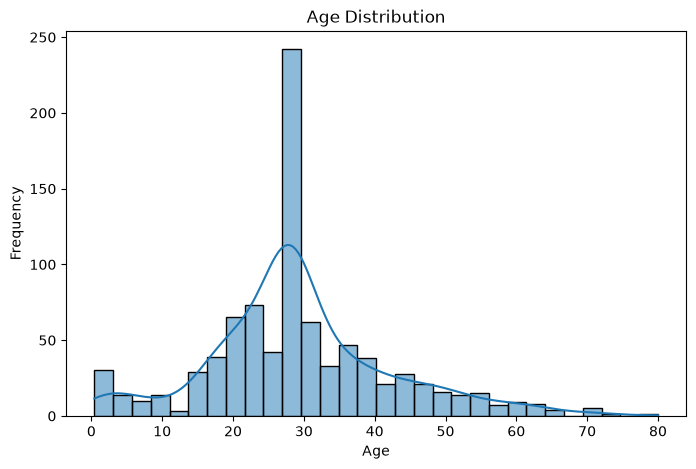

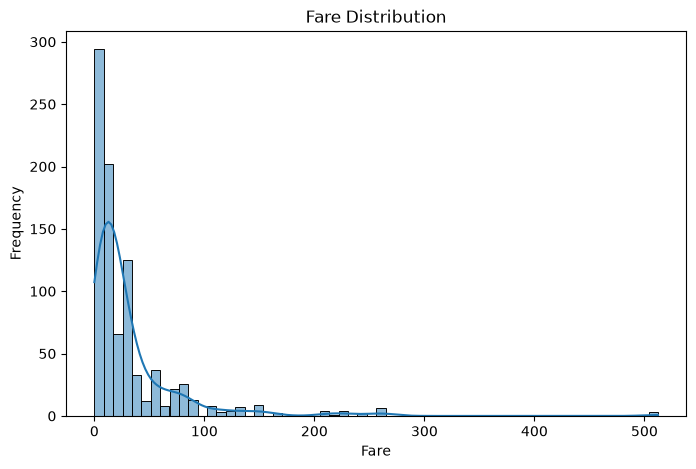

In [9]:
# Task 5: Distribution shape
# Age Distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    data=titanic,
    x="Age",
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


# Fare Distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    data=titanic,
    x="Fare",
    kde=True
)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

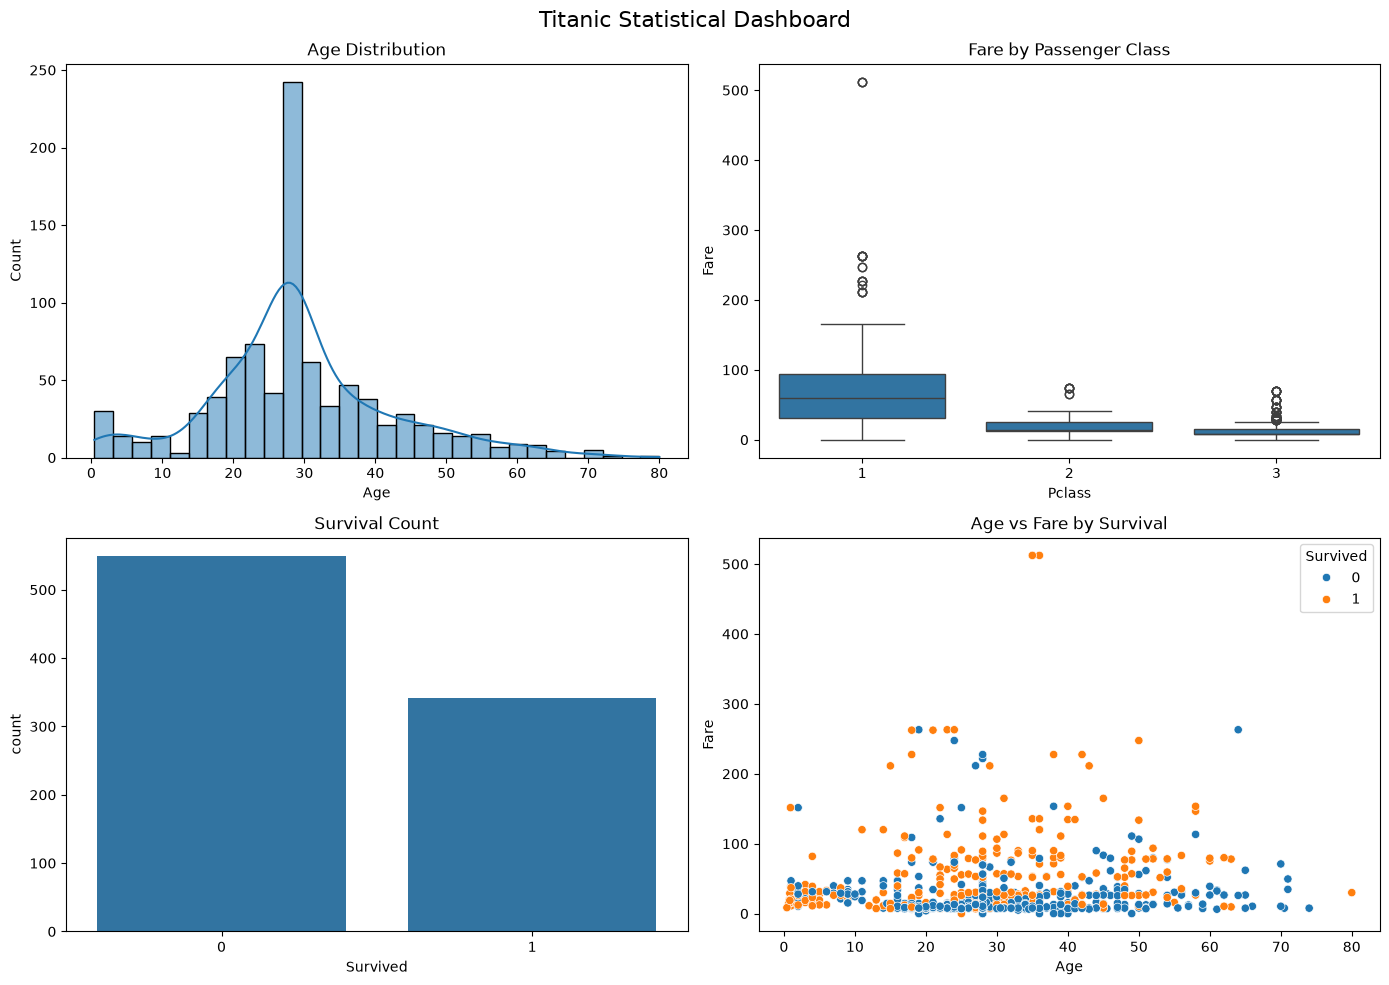

In [ ]:
# Task 6: Multiple charts -- 2x2 dashboard

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fig.suptitle(
    "Titanic Statistical Dashboard",
    fontsize=16
)

# Age Histogram
sns.histplot(
    data=titanic,
    x="Age",
    kde=True,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Age Distribution")


# Fare by Passenger Class
sns.boxplot(
    data=titanic,
    x="Pclass",
    y="Fare",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Fare by Passenger Class")


# Survival Count
sns.countplot(
    data=titanic,
    x="Survived",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Survival Count")


# Age vs Fare
sns.scatterplot(
    data=titanic,
    x="Age",
    y="Fare",
    hue="Survived",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Age vs Fare by Survival")

plt.tight_layout()

plt.show()

## Task 7: Dashboard Interpretation

### 1. Age Distribution

The age distribution is approximately symmetric with slight right skewness. Most passengers were young adults, while relatively few passengers were in the older age groups.

### 2. Fare by Passenger Class

First-class passengers generally paid higher fares and show the greatest fare variability. Several high-fare outliers are visible, especially in first class.

### 3. Survival Count

More passengers did not survive than survived. This indicates that the overall survival rate was relatively low.

### 4. Age vs Fare by Survival

There is no strong linear relationship between age and fare. Higher-fare passengers appear to include more survivors, and several extreme fare outliers are visible.